# Controlled Demand EDA

The generated target combines planned FG demand, actual-production deviations, BOM coefficients, yield/scrap, heteroscedastic process noise, promotions, holidays, shocks and structural shifts. The EDA verifies that the target is neither a smooth sine wave nor arbitrary independent noise.


In [1]:
from pathlib import Path
import json
import pandas as pd
try:
    from IPython.display import Image, display
except ImportError:
    class Image:
        def __init__(self, filename): self.filename = filename
        def __repr__(self): return f"Image({self.filename})"
    def display(value): print(value)

ROOT = Path.cwd()
if ROOT.name != "v8_controlled_synthetic_validation":
    candidate = ROOT / "Ai miroservices/modeling/v8_controlled_synthetic_validation"
    ROOT = candidate if candidate.exists() else ROOT
OUT = ROOT / "outputs"
DATA = OUT / "data"
PLOTS = OUT / "plots"
EVAL = OUT / "evaluator"
summary = json.loads((OUT / "run_summary.json").read_text())


In [2]:
demand = pd.read_csv(DATA / "material_demand.csv", parse_dates=["month"])
demand[["demand_units", "planned_bom_requirement", "actual_bom_requirement"]].describe(percentiles=[.5,.75,.9,.95,.99])


,demand_units,planned_bom_requirement,actual_bom_requirement
count,8640.000000,8640.000000,8640.000000
mean,7691.228531,7670.011065,7693.612931
std,9457.785005,9347.710207,9477.744253
min,112.620000,121.132124,112.512179
50%,4524.315000,4511.746216,4534.873379
75%,10132.265500,10152.991243,10101.063698
90%,17667.348100,17859.032576,17782.635451
95%,23345.970950,23244.261750,23275.117509
99%,47490.037310,47854.270740,47860.666575
max,99067.557000,98869.692591,97386.411655


In [3]:
eda = demand.groupby("material_type").agg(
    materials=("material_id", "nunique"), rows=("material_id", "size"),
    zero_rate=("demand_units", lambda s: (s == 0).mean()),
    mean=("demand_units", "mean"), median=("demand_units", "median"),
    p95=("demand_units", lambda s: s.quantile(.95)), max=("demand_units", "max"),
)
eda


,materials,rows,zero_rate,mean,median,p95,max
material_type,,,,,,,
packaging_material,30,2160,0.0,3261.059146,2832.0695,8501.50110,14969.981
raw_material,90,6480,0.0,9167.951659,6405.7870,26189.02915,99067.557


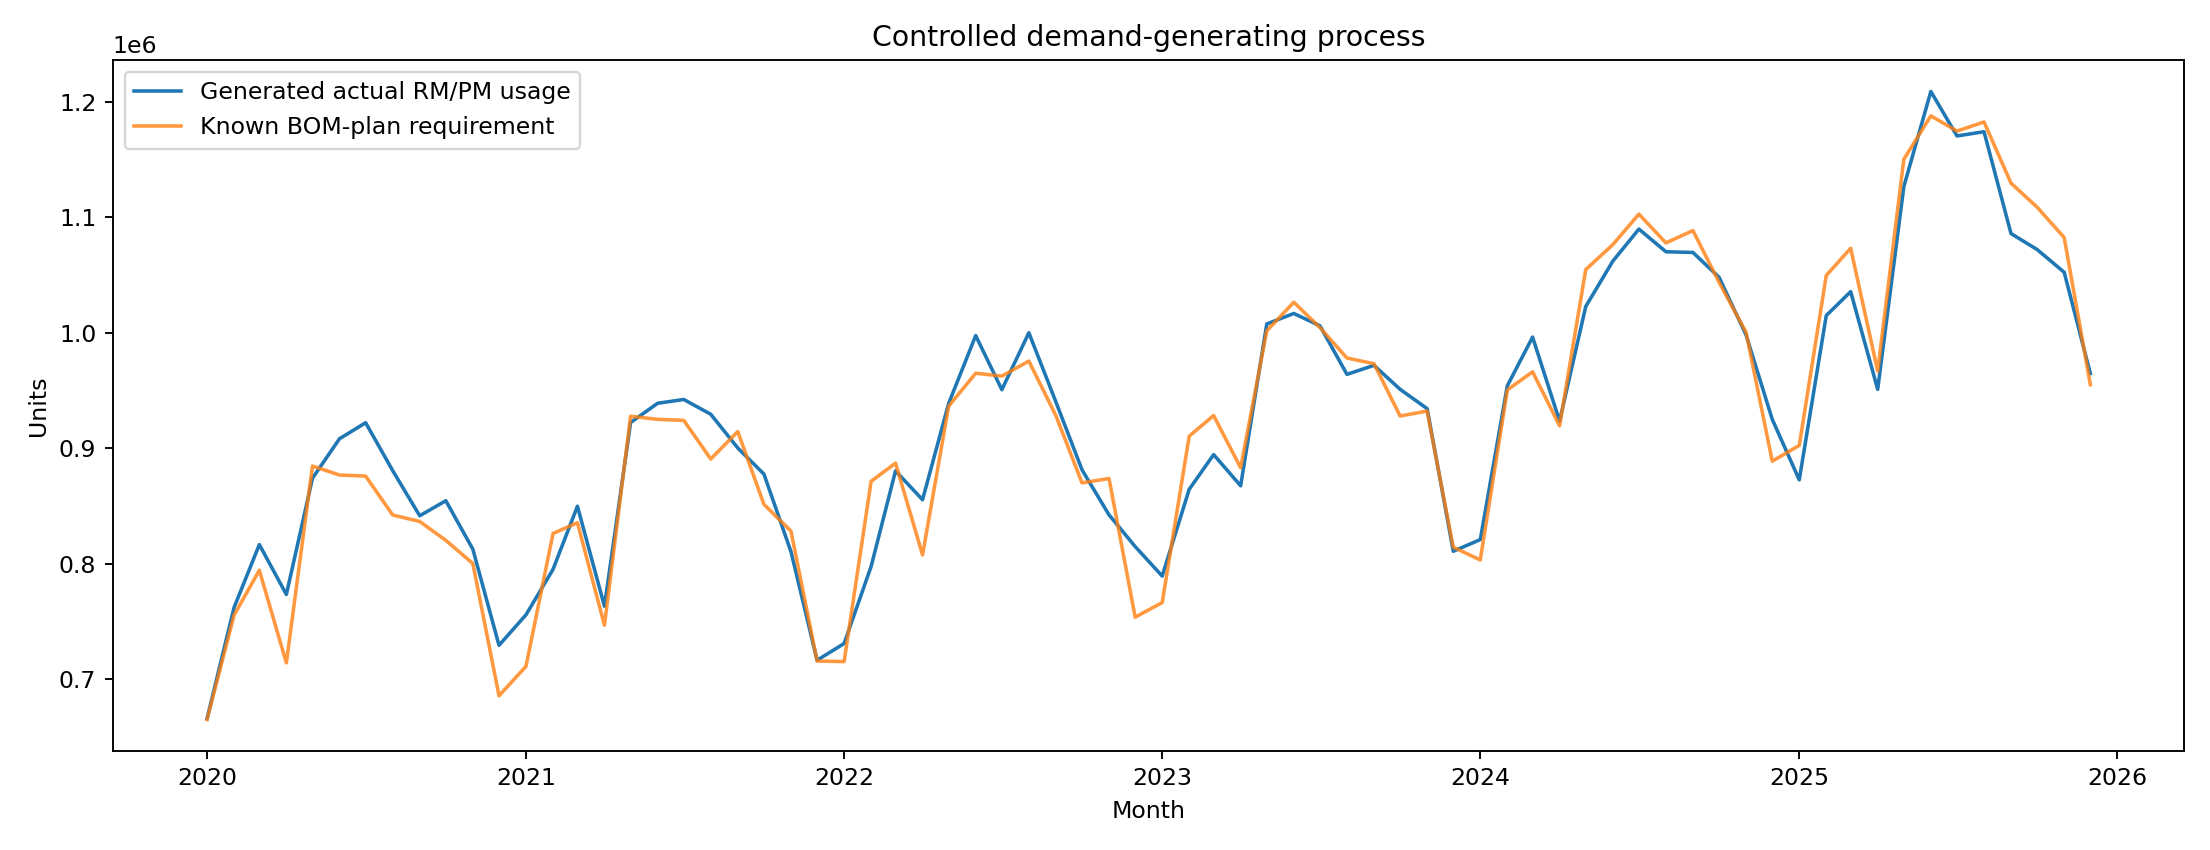

In [4]:
display(Image(filename=str(PLOTS / '01_generated_demand_vs_bom_plan.png')))


In [5]:
evaluator_rows = pd.read_csv(EVAL / "backtest_rows.csv.gz", parse_dates=["forecast_month"])
evaluator_summary = json.loads((EVAL / "evaluator_run_summary.json").read_text())
display(pd.DataFrame([evaluator_summary]).T)


,0
data_tier,CONTROLLED_SYNTHETIC_GROUND_TRUTH
purpose,Independent v8 replication of the shared neura...
history_months,24
horizon_months,12
seeds,"[17, 42, 101, 303, 707]"
production_decision_eligible,False
external_population_validity,UNVERIFIED
leaderboard,"[{'split': 'selection', 'model_name': 'CONV1D_..."


The shared evaluator uses annual and semiannual sine/cosine calendar features and computes Fourier summaries from each historical input window only. This prevents full-series frequency information from leaking into earlier forecast origins.
